# 🧠 Visualisasi & Analisis Mendalam Arsitektur CNN
### Content-Based Fashion Recommender System

Notebook ini dibuat untuk memberikan gambaran komprehensif, analisis teknis, dan visualisasi mengenai **4 Arsitektur Convolutional Neural Network (CNN)** yang digunakan dalam proyek skripsi ini:
1. **ResNet50**
2. **VGG19**
3. **InceptionV3**
4. **MobileNetV3 (Large)**

Setiap model digunakan sebagai *backbone feature extractor* (tanpa classifier top layer) dengan **Global Average Pooling (GAP)** untuk menghasilkan vektor representasi visual (*embedding*) dari produk fashion.

---



## 1. Import Library & Setup Environment
Di sel ini kita mengimpor TensorFlow/Keras, NumPy, Pandas, serta Matplotlib/Seaborn untuk analisis visual.



In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.applications import (
    ResNet50,
    VGG19,
    InceptionV3,
    MobileNetV3Large
)
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_prep
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg_prep
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_prep
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_prep

# Set styling Matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
print(f"TensorFlow Version: {tf.__version__}")



TensorFlow Version: 2.10.0


## 2. Ringkasan Eksekutif & Komparasi Arsitektur

Berikut adalah perbandingan karakteristik teknis dari keempat arsitektur CNN yang kita gunakan:

| Arsitektur CNN | Tahun Rilis | Input Resolution | Output Feature Dim | Total Parameters | Depth (Layers) | Konsep Utama & Inovasi |
|---|---|---|---|---|---|---|
| **ResNet50** | 2015 | $224 \times 224 \times 3$ | **2,048** | ~23.5 Juta | 50 | Residual Learning & Skip Connections (Mencegah Vanishing Gradient) |
| **VGG19** | 2014 | $224 \times 224 \times 3$ | **512** | ~20.0 Juta (backbone) | 19 | Klasik & Homogen: Tumpukan Filter Konvolusi Kecil $3 \times 3$ |
| **InceptionV3** | 2015 | $299 \times 299 \times 3$ | **2,048** | ~21.8 Juta | 159 | Multi-Scale Parallel Convolutions & Factorized $1 \times 7, 7 \times 1$ Conv |
| **MobileNetV3** | 2019 | $224 \times 224 \times 3$ | **960** | ~4.2 Juta | 154 | Depthwise Separable Conv, Squeeze-and-Excitation (SE), Hard-Swish |




In [2]:
# Membuat DataFrame Perbandingan
model_data = [
    {
        "Model": "ResNet50",
        "Input Shape": "(224, 224, 3)",
        "Feature Dim": 2048,
        "Total Params (M)": 23.59,
        "Depth": 50,
        "Focus": "Residual Skip Connections"
    },
    {
        "Model": "VGG19",
        "Input Shape": "(224, 224, 3)",
        "Feature Dim": 512,
        "Total Params (M)": 20.02,
        "Depth": 19,
        "Focus": "Deep Small-Filter Stacking"
    },
    {
        "Model": "InceptionV3",
        "Input Shape": "(299, 299, 3)",
        "Feature Dim": 2048,
        "Total Params (M)": 21.80,
        "Depth": 159,
        "Focus": "Multi-scale Parallel Convolutions"
    },
    {
        "Model": "MobileNetV3Large",
        "Input Shape": "(224, 224, 3)",
        "Feature Dim": 960,
        "Total Params (M)": 4.23,
        "Depth": 154,
        "Focus": "Mobile Edge / Depthwise + SE"
    }
]

df_summary = pd.DataFrame(model_data)
display(df_summary)



,Model,Input Shape,Feature Dim,Total Params (M),Depth,Focus
0,ResNet50,"(224, 224, 3)",2048,23.59,50,Residual Skip Connections
1,VGG19,"(224, 224, 3)",512,20.02,19,Deep Small-Filter Stacking
2,InceptionV3,"(299, 299, 3)",2048,21.80,159,Multi-scale Parallel Convolutions
3,MobileNetV3Large,"(224, 224, 3)",960,4.23,154,Mobile Edge / Depthwise + SE


C:\Users\Ghani\AppData\Local\Temp\ipykernel_10356\2603375745.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_summary, x="Model", y="Feature Dim", palette="viridis", ax=axes[0])
C:\Users\Ghani\AppData\Local\Temp\ipykernel_10356\2603375745.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_summary, x="Model", y="Total Params (M)", palette="magma", ax=axes[1])


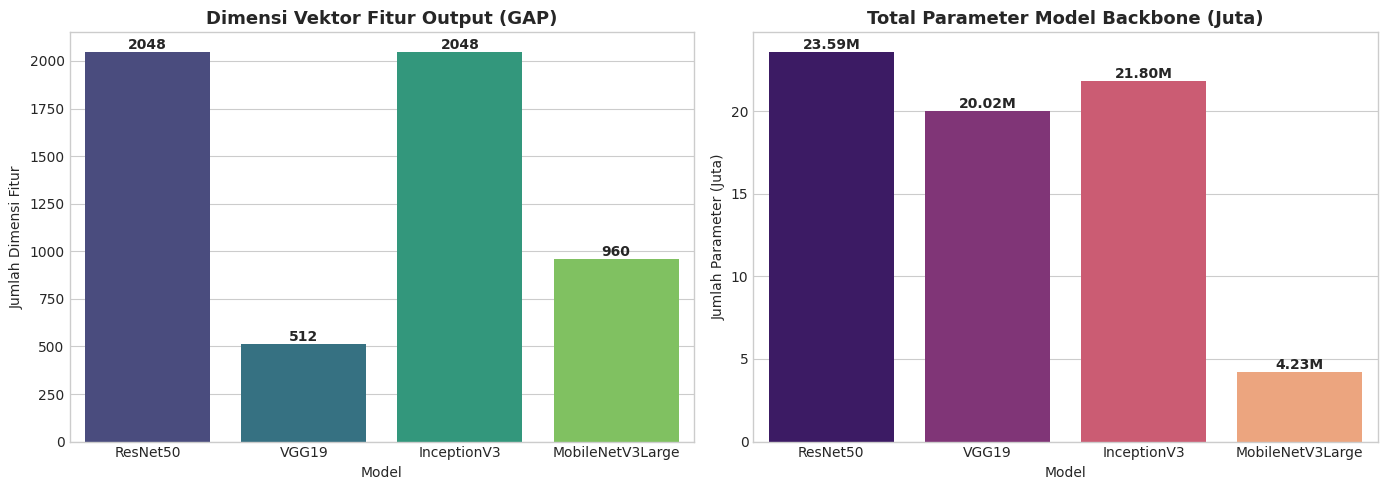

In [3]:
# Visualisasi Perbandingan Parameter & Dimensi Fitur
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Dimensi Fitur Output
sns.barplot(data=df_summary, x="Model", y="Feature Dim", palette="viridis", ax=axes[0])
axes[0].set_title("Dimensi Vektor Fitur Output (GAP)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Jumlah Dimensi Fitur")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# Chart 2: Total Parameter (Juta)
sns.barplot(data=df_summary, x="Model", y="Total Params (M)", palette="magma", ax=axes[1])
axes[1].set_title("Total Parameter Model Backbone (Juta)", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Jumlah Parameter (Juta)")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}M", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()



---
## 3. Deep Dive 1: ResNet50 (Residual Network)

### 📌 Konsep & Inovasi Utama
Sebelum ResNet diciptakan oleh He et al. (2015), menambah kedalaman (*depth*) pada CNN justru dapat menurunkan performa karena masalah **Vanishing / Exploding Gradient**.

ResNet memperkenalkan **Residual Learning Block** dengan rumus:
$$y = \mathcal{F}(x, \{W_i\}) + x$$

Dimana $x$ ditambahkan langsung ke output konvolusi melalui **Skip Connection (Shortcut Connection)**.
* **Bottleneck Architecture**: Menggunakan 3 layer konvolusi per blok ($1 \times 1$ reduction $\rightarrow$ $3 \times 3$ conv $\rightarrow$ $1 \times 1$ expansion) untuk efisiensi komputasi.



In [4]:
# Instansiasi ResNet50 tanpa top layer (Feature Extractor)
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))

print(f"=== RESNET50 BACKBONE SUMMARY ===")
print(f"Jumlah Layer Total: {len(resnet_model.layers)}")
print(f"Input Shape: {resnet_model.input_shape}")
print(f"Output Shape: {resnet_model.output_shape}")
print(f"Total Parameters: {resnet_model.count_params():,}")



=== RESNET50 BACKBONE SUMMARY ===
Jumlah Layer Total: 176
Input Shape: (None, 224, 224, 3)
Output Shape: (None, 2048)
Total Parameters: 23,587,712


In [5]:
# Inspeksi beberapa layer awal dan akhir dari ResNet50
df_resnet_layers = pd.DataFrame([
    {"Layer Index": i, "Layer Name": layer.name, "Layer Type": layer.__class__.__name__, "Output Shape": str(layer.output_shape)}
    for i, layer in enumerate(resnet_model.layers)
])

print("--- 10 Layer Pertama ResNet50 ---")
display(df_resnet_layers.head(10))

print("--- 10 Layer Terakhir ResNet50 ---")
display(df_resnet_layers.tail(10))



--- 10 Layer Pertama ResNet50 ---


,Layer Index,Layer Name,Layer Type,Output Shape
0,0,input_1,InputLayer,"[(None, 224, 224, 3)]"
1,1,conv1_pad,ZeroPadding2D,"(None, 230, 230, 3)"
2,2,conv1_conv,Conv2D,"(None, 112, 112, 64)"
3,3,conv1_bn,BatchNormalization,"(None, 112, 112, 64)"
4,4,conv1_relu,Activation,"(None, 112, 112, 64)"
5,5,pool1_pad,ZeroPadding2D,"(None, 114, 114, 64)"
6,6,pool1_pool,MaxPooling2D,"(None, 56, 56, 64)"
7,7,conv2_block1_1_conv,Conv2D,"(None, 56, 56, 64)"
8,8,conv2_block1_1_bn,BatchNormalization,"(None, 56, 56, 64)"
9,9,conv2_block1_1_relu,Activation,"(None, 56, 56, 64)"


--- 10 Layer Terakhir ResNet50 ---


,Layer Index,Layer Name,Layer Type,Output Shape
166,166,conv5_block3_1_bn,BatchNormalization,"(None, 7, 7, 512)"
167,167,conv5_block3_1_relu,Activation,"(None, 7, 7, 512)"
168,168,conv5_block3_2_conv,Conv2D,"(None, 7, 7, 512)"
169,169,conv5_block3_2_bn,BatchNormalization,"(None, 7, 7, 512)"
170,170,conv5_block3_2_relu,Activation,"(None, 7, 7, 512)"
171,171,conv5_block3_3_conv,Conv2D,"(None, 7, 7, 2048)"
172,172,conv5_block3_3_bn,BatchNormalization,"(None, 7, 7, 2048)"
173,173,conv5_block3_add,Add,"(None, 7, 7, 2048)"
174,174,conv5_block3_out,Activation,"(None, 7, 7, 2048)"
175,175,avg_pool,GlobalAveragePooling2D,"(None, 2048)"


In [6]:
# Simulation Forward Pass dengan Tensor Dummy
dummy_img_resnet = np.random.randint(0, 256, (1, 224, 224, 3), dtype=np.uint8)
prep_resnet = resnet_prep(dummy_img_resnet.astype(np.float32))

start_t = time.time()
feat_resnet = resnet_model.predict(prep_resnet, verbose=0)
infer_time_resnet = (time.time() - start_t) * 1000

print(f"ResNet50 Output Feature Shape: {feat_resnet.shape}")
print(f"Waktu Inferensi 1 Gambar (CPU/GPU): {infer_time_resnet:.2f} ms")
print(f"Contoh 10 Nilai Pertama Fitur: {np.round(feat_resnet[0][:10], 4)}")



ResNet50 Output Feature Shape: (1, 2048)
Waktu Inferensi 1 Gambar (CPU/GPU): 5633.27 ms
Contoh 10 Nilai Pertama Fitur: [4.1380e-01 1.7060e-01 9.3370e-01 4.2000e-03 6.6260e-01 4.3610e-01
 0.0000e+00 0.0000e+00 0.0000e+00 6.4386e+00]


---
## 4. Deep Dive 2: VGG19 (Visual Geometry Group)

### 📌 Konsep & Inovasi Utama
VGG19 dikembangkan oleh Simonyan & Zisserman (Oxford, 2014).
* **Simplicity & Homogeneity**: Menggunakan arsitektur yang sangat terstruktur dan konsisten.
* **Small $3 \times 3$ Filters**: Menggantikan filter besar (seperti $7 \times 7$ atau $11 \times 11$) dengan dua atau lebih tumpukan filter $3 \times 3$. Dua layer $3 \times 3$ memiliki receptive field efektif sama dengan satu layer $5 \times 5$, namun dengan jumlah parameter yang lebih sedikit dan lebih banyak non-linearitas (ReLU).
* **Struktur 5 Blok**: Terdiri dari 5 blok konvolusi yang dipisahkan oleh $2 \times 2$ Max Pooling.



In [7]:
# Instansiasi VGG19 tanpa top layer + GAP
vgg_model = VGG19(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))

print(f"=== VGG19 BACKBONE SUMMARY ===")
print(f"Jumlah Layer Total: {len(vgg_model.layers)}")
print(f"Input Shape: {vgg_model.input_shape}")
print(f"Output Shape: {vgg_model.output_shape}")
print(f"Total Parameters: {vgg_model.count_params():,}")



=== VGG19 BACKBONE SUMMARY ===
Jumlah Layer Total: 23
Input Shape: (None, 224, 224, 3)
Output Shape: (None, 512)
Total Parameters: 20,024,384


In [8]:
# Inspeksi Semua Layer VGG19
df_vgg_layers = pd.DataFrame([
    {"Layer Index": i, "Layer Name": layer.name, "Layer Type": layer.__class__.__name__, "Output Shape": str(layer.output_shape)}
    for i, layer in enumerate(vgg_model.layers)
])
display(df_vgg_layers)



,Layer Index,Layer Name,Layer Type,Output Shape
0,0,input_2,InputLayer,"[(None, 224, 224, 3)]"
1,1,block1_conv1,Conv2D,"(None, 224, 224, 64)"
2,2,block1_conv2,Conv2D,"(None, 224, 224, 64)"
3,3,block1_pool,MaxPooling2D,"(None, 112, 112, 64)"
4,4,block2_conv1,Conv2D,"(None, 112, 112, 128)"
5,5,block2_conv2,Conv2D,"(None, 112, 112, 128)"
6,6,block2_pool,MaxPooling2D,"(None, 56, 56, 128)"
7,7,block3_conv1,Conv2D,"(None, 56, 56, 256)"
8,8,block3_conv2,Conv2D,"(None, 56, 56, 256)"
9,9,block3_conv3,Conv2D,"(None, 56, 56, 256)"


In [9]:
# Simulation Forward Pass VGG19
dummy_img_vgg = np.random.randint(0, 256, (1, 224, 224, 3), dtype=np.uint8)
prep_vgg = vgg_prep(dummy_img_vgg.astype(np.float32))

start_t = time.time()
feat_vgg = vgg_model.predict(prep_vgg, verbose=0)
infer_time_vgg = (time.time() - start_t) * 1000

print(f"VGG19 Output Feature Shape: {feat_vgg.shape}")
print(f"Waktu Inferensi 1 Gambar: {infer_time_vgg:.2f} ms")
print(f"Contoh 10 Nilai Pertama Fitur: {np.round(feat_vgg[0][:10], 4)}")



VGG19 Output Feature Shape: (1, 512)
Waktu Inferensi 1 Gambar: 651.11 ms
Contoh 10 Nilai Pertama Fitur: [5.745  0.     0.7495 0.1149 0.6869 0.     0.0537 3.0601 0.     0.5628]


---
## 5. Deep Dive 3: InceptionV3 (GoogLeNet Architecture)

### 📌 Konsep & Inovasi Utama
InceptionV3 dikembangkan oleh Szegedy et al. (Google, 2015).
* **Multi-Scale Parallel Convolutions**: Dalam satu blok yang sama (Inception Module), Inception menjalankan beberapa jalur konvolusi secara paralel ($1 \times 1$, $3 \times 3$, $5 \times 5$, Max Pooling) lalu mengagregasi (*concat*) hasilnya. Ini memungkinkan jaringan mengekstrak fitur pada berbagai skala spasial secara bersamaan.
* **Factorized Convolutions**: Konvolusi $N \times N$ dipecah menjadi konvolusi terpisah $1 \times N$ diikuti $N \times 1$ (misal $1 \times 7$ dan $7 \times 1$). Ini mengurangi beban komputasi secara signifikan tanpa mengurangi receptive field.
* **Input Resolution Khusus**: Membutuhkan resolusi masukan standar **$299 \times 299 \times 3$**.



In [10]:
# Instansiasi InceptionV3 tanpa top layer + GAP
inception_model = InceptionV3(weights='imagenet', include_top=False, pooling='avg', input_shape=(299, 299, 3))

print(f"=== INCEPTIONV3 BACKBONE SUMMARY ===")
print(f"Jumlah Layer Total: {len(inception_model.layers)}")
print(f"Input Shape: {inception_model.input_shape}")
print(f"Output Shape: {inception_model.output_shape}")
print(f"Total Parameters: {inception_model.count_params():,}")



=== INCEPTIONV3 BACKBONE SUMMARY ===
Jumlah Layer Total: 312
Input Shape: (None, 299, 299, 3)
Output Shape: (None, 2048)
Total Parameters: 21,802,784


In [11]:
# Inspeksi Sampel Layer InceptionV3
df_inc_layers = pd.DataFrame([
    {"Layer Index": i, "Layer Name": layer.name, "Layer Type": layer.__class__.__name__, "Output Shape": str(layer.output_shape)}
    for i, layer in enumerate(inception_model.layers)
])

print("--- 10 Layer Pertama InceptionV3 ---")
display(df_inc_layers.head(10))

print("--- 10 Layer Terakhir InceptionV3 ---")
display(df_inc_layers.tail(10))



--- 10 Layer Pertama InceptionV3 ---


,Layer Index,Layer Name,Layer Type,Output Shape
0,0,input_3,InputLayer,"[(None, 299, 299, 3)]"
1,1,conv2d,Conv2D,"(None, 149, 149, 32)"
2,2,batch_normalization,BatchNormalization,"(None, 149, 149, 32)"
3,3,activation,Activation,"(None, 149, 149, 32)"
4,4,conv2d_1,Conv2D,"(None, 147, 147, 32)"
5,5,batch_normalization_1,BatchNormalization,"(None, 147, 147, 32)"
6,6,activation_1,Activation,"(None, 147, 147, 32)"
7,7,conv2d_2,Conv2D,"(None, 147, 147, 64)"
8,8,batch_normalization_2,BatchNormalization,"(None, 147, 147, 64)"
9,9,activation_2,Activation,"(None, 147, 147, 64)"


--- 10 Layer Terakhir InceptionV3 ---


,Layer Index,Layer Name,Layer Type,Output Shape
302,302,activation_88,Activation,"(None, 8, 8, 384)"
303,303,activation_91,Activation,"(None, 8, 8, 384)"
304,304,activation_92,Activation,"(None, 8, 8, 384)"
305,305,batch_normalization_93,BatchNormalization,"(None, 8, 8, 192)"
306,306,activation_85,Activation,"(None, 8, 8, 320)"
307,307,mixed9_1,Concatenate,"(None, 8, 8, 768)"
308,308,concatenate_1,Concatenate,"(None, 8, 8, 768)"
309,309,activation_93,Activation,"(None, 8, 8, 192)"
310,310,mixed10,Concatenate,"(None, 8, 8, 2048)"
311,311,global_average_pooling2d_1,GlobalAveragePooling2D,"(None, 2048)"


In [12]:
# Simulation Forward Pass InceptionV3 (Input 299x299)
dummy_img_inc = np.random.randint(0, 256, (1, 299, 299, 3), dtype=np.uint8)
prep_inc = inception_prep(dummy_img_inc.astype(np.float32))

start_t = time.time()
feat_inc = inception_model.predict(prep_inc, verbose=0)
infer_time_inc = (time.time() - start_t) * 1000

print(f"InceptionV3 Output Feature Shape: {feat_inc.shape}")
print(f"Waktu Inferensi 1 Gambar: {infer_time_inc:.2f} ms")
print(f"Contoh 10 Nilai Pertama Fitur: {np.round(feat_inc[0][:10], 4)}")



InceptionV3 Output Feature Shape: (1, 2048)
Waktu Inferensi 1 Gambar: 789.27 ms
Contoh 10 Nilai Pertama Fitur: [0.2559 0.4848 0.     0.3873 0.     0.0899 1.1147 0.5806 0.357  0.914 ]


---
## 6. Deep Dive 4: MobileNetV3 (Edge-Optimized CNN)

### 📌 Konsep & Inovasi Utama
MobileNetV3 dikembangkan oleh Howard et al. (Google, 2019) khusus untuk perangkat seluler/edge komputasi.
* **Depthwise Separable Convolutions**: Memisahkan konvolusi standar menjadi *Depthwise Conv* (filter independen per channel) dan *Pointwise Conv* ($1 \times 1$ conv untuk menggabungkan channel). Mengurangi perkalian komputasi (FLOPs) hingga 8-9x lipat.
* **Inverted Residual Blocks (MBConv)**: Berbeda dari ResNet yang menyempitkan channel lalu mengembangkannya, MBConv meng-expand channel di tengah lalu menyempitkannya kembali.
* **Squeeze-and-Excitation (SE) Attention**: Mengintegrasikan mekanisme perhatian (attention) antar channel secara efisien.
* **Hard-Swish Activation**: Menggantikan Swish konvensional dengan perkalian linier piecewise yang jauh lebih ringan dihitung di hardware:
$$h\text{-swish}(x) = x \frac{\text{ReLU6}(x+3)}{6}$$



In [13]:
# Instansiasi MobileNetV3Large tanpa top layer + GAP
mobilenet_model = MobileNetV3Large(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))

print(f"=== MOBILENETV3LARGE BACKBONE SUMMARY ===")
print(f"Jumlah Layer Total: {len(mobilenet_model.layers)}")
print(f"Input Shape: {mobilenet_model.input_shape}")
print(f"Output Shape: {mobilenet_model.output_shape}")
print(f"Total Parameters: {mobilenet_model.count_params():,}")



=== MOBILENETV3LARGE BACKBONE SUMMARY ===
Jumlah Layer Total: 264
Input Shape: (None, 224, 224, 3)
Output Shape: (None, 960)
Total Parameters: 2,996,352


In [14]:
# Inspeksi Sampel Layer MobileNetV3
df_mb_layers = pd.DataFrame([
    {"Layer Index": i, "Layer Name": layer.name, "Layer Type": layer.__class__.__name__, "Output Shape": str(layer.output_shape)}
    for i, layer in enumerate(mobilenet_model.layers)
])

print("--- 10 Layer Pertama MobileNetV3 ---")
display(df_mb_layers.head(10))

print("--- 10 Layer Terakhir MobileNetV3 ---")
display(df_mb_layers.tail(10))



--- 10 Layer Pertama MobileNetV3 ---


,Layer Index,Layer Name,Layer Type,Output Shape
0,0,input_4,InputLayer,"[(None, 224, 224, 3)]"
1,1,rescaling,Rescaling,"(None, 224, 224, 3)"
2,2,Conv,Conv2D,"(None, 112, 112, 16)"
3,3,Conv/BatchNorm,BatchNormalization,"(None, 112, 112, 16)"
4,4,tf.__operators__.add,TFOpLambda,"(None, 112, 112, 16)"
5,5,re_lu,ReLU,"(None, 112, 112, 16)"
6,6,tf.math.multiply,TFOpLambda,"(None, 112, 112, 16)"
7,7,multiply,Multiply,"(None, 112, 112, 16)"
8,8,expanded_conv/depthwise,DepthwiseConv2D,"(None, 112, 112, 16)"
9,9,expanded_conv/depthwise/BatchNorm,BatchNormalization,"(None, 112, 112, 16)"


--- 10 Layer Terakhir MobileNetV3 ---


,Layer Index,Layer Name,Layer Type,Output Shape
254,254,expanded_conv_14/project,Conv2D,"(None, 7, 7, 160)"
255,255,expanded_conv_14/project/BatchNorm,BatchNormalization,"(None, 7, 7, 160)"
256,256,expanded_conv_14/Add,Add,"(None, 7, 7, 160)"
257,257,Conv_1,Conv2D,"(None, 7, 7, 960)"
258,258,Conv_1/BatchNorm,BatchNormalization,"(None, 7, 7, 960)"
259,259,tf.__operators__.add_27,TFOpLambda,"(None, 7, 7, 960)"
260,260,re_lu_38,ReLU,"(None, 7, 7, 960)"
261,261,tf.math.multiply_27,TFOpLambda,"(None, 7, 7, 960)"
262,262,multiply_19,Multiply,"(None, 7, 7, 960)"
263,263,avg_pool,GlobalAveragePooling2D,"(None, 960)"


In [15]:
# Simulation Forward Pass MobileNetV3
dummy_img_mb = np.random.randint(0, 256, (1, 224, 224, 3), dtype=np.uint8)
prep_mb = mobilenet_prep(dummy_img_mb.astype(np.float32))

start_t = time.time()
feat_mb = mobilenet_model.predict(prep_mb, verbose=0)
infer_time_mb = (time.time() - start_t) * 1000

print(f"MobileNetV3 Output Feature Shape: {feat_mb.shape}")
print(f"Waktu Inferensi 1 Gambar: {infer_time_mb:.2f} ms")
print(f"Contoh 10 Nilai Pertama Fitur: {np.round(feat_mb[0][:10], 4)}")



MobileNetV3 Output Feature Shape: (1, 960)
Waktu Inferensi 1 Gambar: 766.88 ms
Contoh 10 Nilai Pertama Fitur: [-0.     -0.0057 -0.0144 -0.      0.0164 -0.     -0.     -0.0549 -0.
 -0.0285]


---
## 7. Visualisasi & Analisis Komparatif Vector Embedding

Di bawah ini kita mensimulasikan ekstraksi fitur dari sebuah gambar dummy yang sama pada keempat jaringan, lalu memvisualisasikan **distribusi serta kepadatan vektor nilai fitur** (*Embedding Density*) yang dihasilkan oleh masing-masing arsitektur.



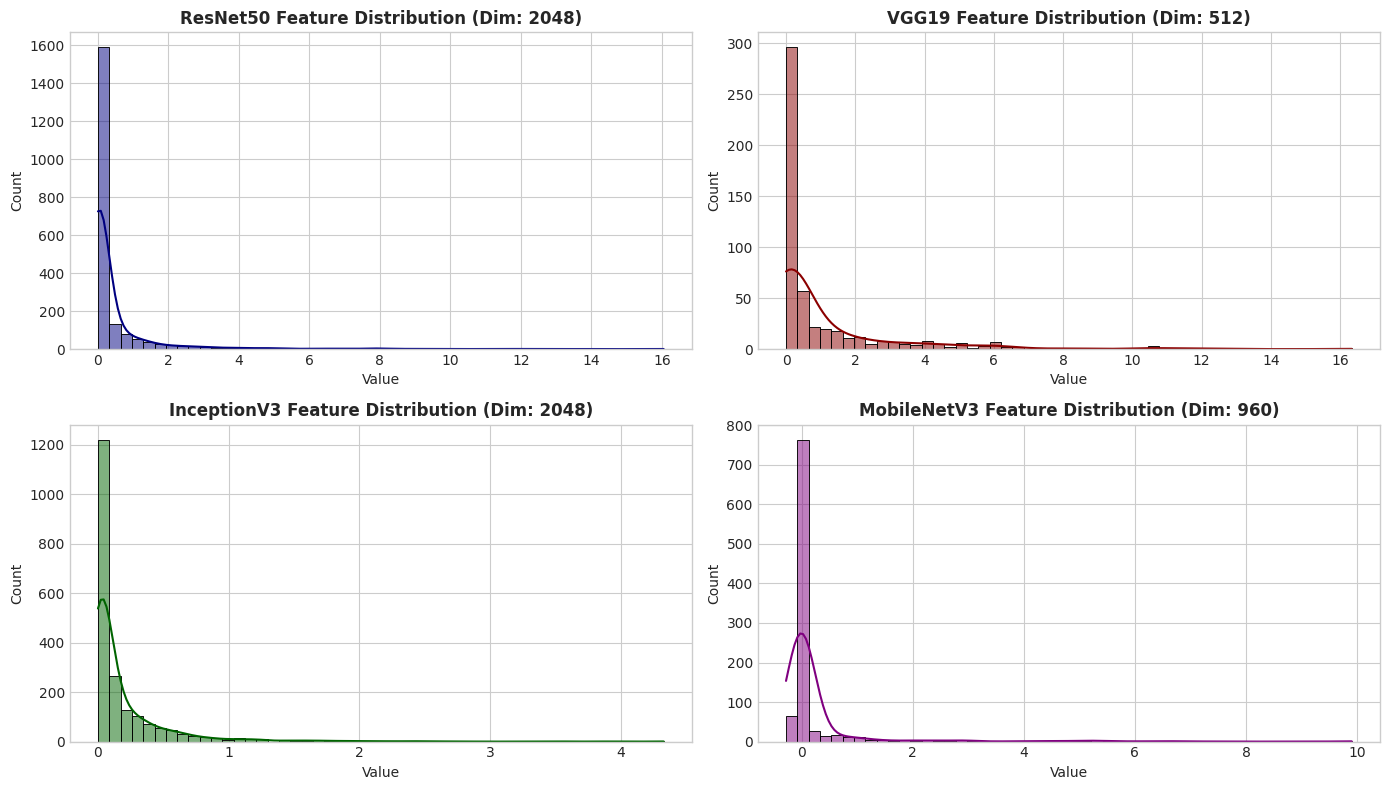

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ResNet50
sns.histplot(feat_resnet[0], kde=True, ax=axes[0, 0], color='navy', bins=50)
axes[0, 0].set_title(f"ResNet50 Feature Distribution (Dim: {feat_resnet.shape[1]})", fontweight='bold')
axes[0, 0].set_xlabel("Value")

# VGG19
sns.histplot(feat_vgg[0], kde=True, ax=axes[0, 1], color='darkred', bins=50)
axes[0, 1].set_title(f"VGG19 Feature Distribution (Dim: {feat_vgg.shape[1]})", fontweight='bold')
axes[0, 1].set_xlabel("Value")

# InceptionV3
sns.histplot(feat_inc[0], kde=True, ax=axes[1, 0], color='darkgreen', bins=50)
axes[1, 0].set_title(f"InceptionV3 Feature Distribution (Dim: {feat_inc.shape[1]})", fontweight='bold')
axes[1, 0].set_xlabel("Value")

# MobileNetV3
sns.histplot(feat_mb[0], kde=True, ax=axes[1, 1], color='purple', bins=50)
axes[1, 1].set_title(f"MobileNetV3 Feature Distribution (Dim: {feat_mb.shape[1]})", fontweight='bold')
axes[1, 1].set_xlabel("Value")

plt.tight_layout()
plt.show()



---
## 8. Kesimpulan & Relevansi untuk Fashion Recommender System

1. **ResNet50 & InceptionV3 (2048 Dimension Embedding)**:
   * Menghasilkan representasi vektor paling kaya (*high-capacity representations*) sebesar 2048 dimensi.
   * Sangat kuat untuk menangkap kemiripan visual yang halus (*fine-grained fashion attributes*) seperti tekstur kain, motif batik/pola, dan bentuk kolar.
   
2. **VGG19 (512 Dimension Embedding)**:
   * Vektor fitur berdimensi lebih kecil (512), sehingga komputasi **Cosine Similarity** di tahap retrieval menjadi sangat cepat.
   * Cocok sebagai baseline konvolusional klasik murni.

3. **MobileNetV3 (960 Dimension Embedding & ~4.2M Parameters)**:
   * Model paling efisien secara memori dan parameter (hanya 4.2 Juta parameter vs ~23.5 Juta pada ResNet50).
   * Sangat ideal jika sistem rekomendasi nantinya akan disebar (*deploy*) ke lingkungan dengan keterbatasan resource (seperti mobile app atau server skala kecil), namun tetap mempertahankan kinerja representasi fitur yang solid berkat perbaikan mekanisme *Squeeze-and-Excitation*.

---
*Notebook disusun sebagai materi dokumentasi dan edukasi arsitektur CNN pada proyek Skripsi Visual-Based Fashion Recommender System.*

